In [1]:
# Test script 3

In [5]:
import os
import xarray as xr
import numpy as np
import dask.array as da
import matplotlib.pyplot as plt
from utils.mortality_utils import att_frac
from utils.mortality_utils import mortality

In [6]:
# === Path config ===
BMR_DIR = "/glade/work/awells/air_quality/BMR/"
POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"
O3_DIR = "/glade/work/awells/air_quality/CESM/ozone/OSDMA8_BC/"

In [3]:
# === Load data ===
bmr_file = "GBD_BMR_Country_Mask_COPD_1990-2009.nc"
bmr_path = os.path.join(BMR_DIR, bmr_file)
BMR = xr.open_dataarray(bmr_path)  # three quantiles

pop_file = "ssp2_coarse_grid_annual_2000-2100.nc"
pop_path = os.path.join(POP_DIR, pop_file)
population = xr.open_dataarray(pop_path)

In [7]:
# === Path config ===
SAVE_DIR = "/glade/work/awells/air_quality/CESM/mortality/"
scenario = "ARISE"
ens_num = 1

print(f"Processing {scenario}, Ensemble {ens_num:02d}")
if scenario == "ARISE":
    dates = "2035-2068"
elif scenario == "SSP245":
    dates = "2020-2068"

o3_file = f"OSDMA8_BC_CESM2_{scenario}_{ens_num:02d}_{dates}.nc"
o3_path = os.path.join(O3_DIR, o3_file)
o3 = xr.open_dataarray(o3_path)

# Adjust indices to match (with small tolerance)
# e.g., max 1e-7 km distance
o3 = o3.reindex_like(BMR, method="nearest", tolerance=1e-9, fill_value=0)
population = population.reindex_like(BMR, method="nearest", tolerance=1e-9)

# Flag if any nans present (i.e. reindex was out of tolerance distance)
assert not population.isnull().any()

Processing ARISE, Ensemble 01


In [22]:
n_samples = 1000

# === Scalar distributions ===
# TMREL
tmrel_mean = 32.4
tmrel_std = (35.7 - 29.1) / (2 * 1.96)
tmrel_samples = np.random.normal(tmrel_mean, tmrel_std, size=n_samples)

# Beta from RR_10
RR_10 = 1.074
RR_10_lower = 1.014
RR_10_upper = 1.137
beta_mean = np.log(RR_10) / 10
beta_std = (np.log(RR_10_upper) - np.log(RR_10_lower)) / (2 * 1.96 * 10)
beta_samples = np.random.normal(beta_mean, beta_std, size=n_samples)

# Convert to Dask for broadcasting
tmrel_dask = da.from_array(tmrel_samples[:, np.newaxis, np.newaxis], chunks=(100, 1, 1))
beta_dask = da.from_array(beta_samples[:, np.newaxis, np.newaxis], chunks=(100, 1, 1))

In [23]:
def monte_carlo(n_samples, BMR, POP, O3):
    lat = BMR['lat']
    lon = BMR['lon']

    # === BMR ===
    bmr_m = BMR.sel(quantile="mean")
    bmr_l = BMR.sel(quantile="lower")
    bmr_u = BMR.sel(quantile="upper")

    BMR_mean = bmr_m.chunk({'lat': 180, 'lon': 360})
    BMR_lower = bmr_l.chunk({'lat': 180, 'lon': 360})
    BMR_upper = bmr_u.chunk({'lat': 180, 'lon': 360})

    # Standard deviation for BMR
    bmr_std = (BMR_upper - BMR_lower) / (2 * 1.96)

    # Sample BMR: shape = (samples, lat, lon)
    bmr_samples = da.random.normal(
        loc=BMR_mean.data, scale=bmr_std.data,
        size=(n_samples, len(lat), len(lon)),
        chunks=(100, 180, 360))

    POP = POP.chunk({'lat': 180, 'lon': 360})
    O3 = O3.chunk({'lat': 180, 'lon': 360})

    # Broadcast POP and x to sample dimension
    pop_samples = da.broadcast_to(POP.data, (n_samples, len(lat), len(lon)))
    O3_samples = da.broadcast_to(O3.data, (n_samples, len(lat), len(lon)))

    return bmr_samples, pop_samples, O3_samples

In [25]:
BMR_samples, POP_samples, O3_samples = monte_carlo(n_samples, BMR, population.sel(year=2035), o3.sel(year=2035))
AF = att_frac(O3_samples, tmrel_dask, beta_dask)
M = mortality(AF, BMR_samples, POP_samples)

/glade/work/awells/conda-envs/my-env/lib/python3.12/site-packages/dask/array/core.py:4867: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(


In [31]:
m_da.sum(dim=("lat", "lon")).compute()

<xarray.DataArray 'Mortality (COPD) due to surface ozone' (sample: 1000)> Size: 8kB
array([ 606003.88965574,  544733.31103604,  498309.04383602,
        345183.03915921,  648432.52731321,  397225.78181827,
        793343.80897771,  486394.73312445,  351704.62853587,
        726859.65632988,  582557.42984261,  844326.45507475,
        398681.45749219,  630879.25496086,  504758.36122135,
        397940.15673565,  334658.32029254,  561774.88571841,
        423086.16430904,   36849.74178874,  340950.81718108,
        307105.16551512,  577506.25280111,  460669.59377752,
        539590.35852801,  643913.17683783,  232952.53272837,
        342678.72579887,  315959.47684388,  567096.49094801,
        600769.98624432,  443969.67614495,  450197.65251347,
        822812.9097051 ,  411173.03103387,  662173.0787724 ,
        417682.52837364,  585176.02819498,  520420.02907279,
        507159.44029513,  454070.15332322,  410002.27983043,
        483171.53136484,  617445.33302426,  498990.13591319,
        592716.43145975,  470495.71501789,  438945.18914996,
        405430.57487343,  840093.78880619,  409877.43655265,
        368591.54077547,  769074.03089543,  362910.62206569,
        496552.42886146,  629314.61755238,  694787.42867553,
        723699.38708626,  623238.03230383,  596430.88418228,
...
        624406.37489631,  506133.78226279,  -60081.99514945,
        456792.85578853,  113344.14562774,  323337.67085147,
        622459.84420076,  780307.47467788,  582556.56035887,
        -56792.51893955,  833349.67628425,  876498.78814257,
        341445.88129151,  520140.23385669,  554347.61006123,
        395756.39252662,  628874.38289129,  483241.58897092,
        508483.94322427,  299942.2633166 ,  659557.22642991,
        667182.28066656,  613190.0203747 ,  458947.30891326,
        525186.94704446,  736058.95352091,  277195.80540574,
        671136.83397859,  412910.01075885,  110195.79663167,
        385154.82551099,  541400.68286856,  333608.26835032,
        290915.20380043,  506622.50070091,  334223.47388658,
        392413.70437723,  608629.01828578,  279974.5668655 ,
        805030.81583495,  506399.30637359,  508672.00255931,
        794115.47660176,  547618.86166505,  531901.91507104,
        507981.50865332,  756026.71682988,  583441.40607477,
        540193.86874292,  381776.75195286,  638203.51908134,
        372497.86344899,  516324.93400057,  760290.82852227,
        427838.48290886,  518010.79660844,  399624.32544515,
        382287.00315589])
Coordinates:
  * sample   (sample) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

In [27]:
m_da = xr.DataArray(
    M,
    dims=("sample", "lat", "lon"),
    coords={"sample": np.arange(n_samples), "lat": lat, "lon": lon},
    name="Mortality (COPD) due to surface ozone"
)

In [42]:
m_da.mean().compute().values

array(0.32548988)

In [12]:
m_da = xr.DataArray(
    m_samples,
    dims=("sample", "lat", "lon"),
    coords={"sample": np.arange(n_samples), "lat": lat, "lon": lon},
    name="M"
)

# Summarize (trigger compute here)
m_sum = m_da.sum(dim="sample").compute()
m_ci_lower = m_da.quantile(0.025, dim="sample").compute()
m_ci_upper = m_da.quantile(0.975, dim="sample").compute()


KeyboardInterrupt



In [16]:
# Rechunk along the 'sample' dimension to a single chunk
m_da = m_da.chunk({"sample": -1})

# Now quantile will work
m_ci_lower = m_da.quantile(0.025, dim="sample").compute()
m_ci_upper = m_da.quantile(0.975, dim="sample").compute()

In [33]:
m_da.mean("sample").compute()

KeyboardInterrupt: 

In [14]:
m_globalsum = m_da.sum(dim=("lat", "lon"))

In [20]:
m_globalsum.mean().compute().values

array(480307.39351152)

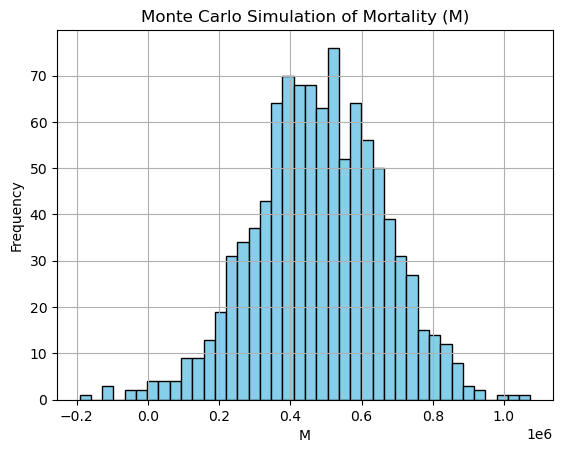

In [15]:
plt.hist(m_globalsum, bins=40, color='skyblue', edgecolor='k')
plt.title("Monte Carlo Simulation of Mortality (M)")
plt.xlabel("M")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [25]:
m_globalmean.mean().values

array(0.3219061)

In [30]:
m_da = xr.DataArray(
    bmr_samples,
    dims=("sample", "lat", "lon"),
    coords={"sample": np.arange(n_samples), "lat": lat, "lon": lon},
    name="bmr"
)

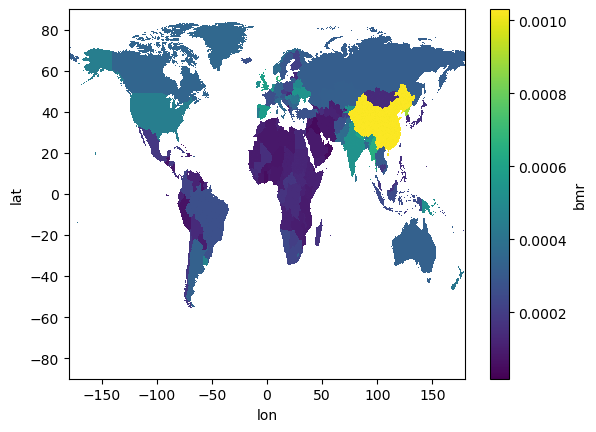

In [33]:
m_da.mean("sample").compute().plot()